# Downstream Exploitation of Space Data
## Session 8: Deep Learning

### Learning Objectives

You will: 
* know some of the problems deep learning solves and see some examples
* be able to reduce complex data (spectra) in dimensionality with an autoencoder
* know what Leave-One-Out Cross-Validation is

In [1]:
import numpy as np
import polars as pl
import math
import copy
from matplotlib import pyplot as plt

from gaiaxpy import pwl_to_wl

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [9]:
plt.rc('font',   size=16)          # controls default text sizes
plt.rc('axes',   titlesize=16)     # fontsize of the axes title
plt.rc('axes',   labelsize=16)     # fontsize of the x and y labels
plt.rc('xtick',  labelsize=14)     # fontsize of the tick labels
plt.rc('ytick',  labelsize=14)     # fontsize of the tick labels
plt.rc('legend', fontsize=16)      # legend fontsize
plt.rc('figure', titlesize=16)     # fontsize of the figure title

### Spectra

In two previous sessions, we worked with photometry, that is brightness measurements of stars. Today we will look at another data type in astronomy, spectroscopy. Spectroscopy analyzes the detailed composition of light (wavelength vs intensity). Let's take a look at the dataset of low-resolution spectroscopy of the Gaia satellite:

In [2]:
df = pl.read_parquet('gaia_xp.parquet')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [3]:
df

source_id,xp,flux,flux_error,_batch_start,_batch_stop
i64,str,list[f64],list[f64],i32,i32
2159088791369547776,"""BP""","[26.077906, 46.44584, … -5.04526]","[4.801991, 4.897875, … 1.684505]",0,5000
2159088791369547776,"""RP""","[9.614504, 21.036374, … 7.687874]","[1.217201, 1.037496, … 0.913512]",0,5000
2235848653043761152,"""BP""","[332.301829, 516.85887, … -40.72752]","[39.800481, 40.427836, … 17.919141]",0,5000
2235848653043761152,"""RP""","[85.219637, 170.541904, … 55.660832]","[9.244108, 7.974658, … 6.902839]",0,5000
2249963526189187072,"""BP""","[44.541795, 94.741629, … -19.194039]","[8.883945, 9.194146, … 2.410567]",0,5000
…,…,…,…,…,…
2055463428247076352,"""RP""","[30.861416, 68.323512, … 45.274668]","[3.573135, 2.822916, … 3.07912]",5000,6291
2132679724664397568,"""BP""","[-50.486121, 49.203901, … 39.159112]","[73.91983, 83.81674, … 24.848265]",5000,6291
2132679724664397568,"""RP""","[114.996636, 224.493353, … 98.549106]","[20.23037, 16.192477, … 14.522405]",5000,6291


Note that for each source (star), there is spectra from the blue spectrophotometer (BP) and the red spectrophotometer (RP).

**Discuss with your neighbour:** What does blue and red mean for light?

Let's get one random star and look at its BP and RP spectra (together we call them XP):

In [24]:
rng = np.random.default_rng(42)
sids = df.select("source_id").unique().to_series().to_list()
sid = rng.choice(sids)

print("Selected source_id:", sid)

Selected source_id: 1897216526434523776


In [25]:
df_ = df.filter(pl.col("source_id") == sid)

In [26]:
n = (
    df.filter(pl.col("xp") == "BP")
      .select("flux")
      .to_series()[0]
      .__len__()
)

sampling = np.arange(n)

In [27]:
colors = {"BP": "blue", "RP": "red"}

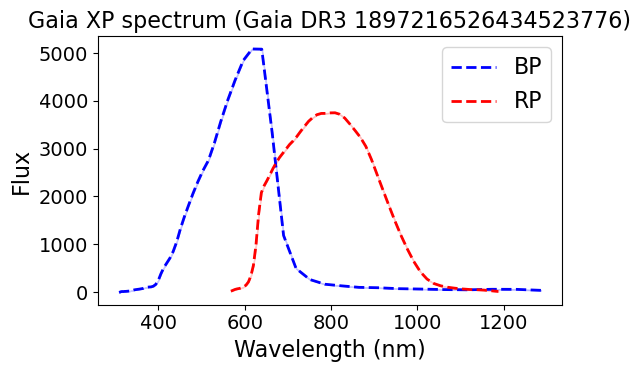

In [28]:
plt.figure(figsize=(6, 4))

for band in ["BP", "RP"]:
    sub = df_.filter(pl.col("xp") == band)

    flux = sub.select("flux").explode("flux").to_numpy().flatten()
    flux_err = sub.select("flux_error").explode("flux_error").to_numpy().flatten()

    wl = pwl_to_wl(band, sampling)

    plt.plot(wl, flux, color=colors[band], lw=2, ls='--', label=band)
    plt.fill_between(
        wl,
        flux - flux_err,
        flux + flux_err,
        color=colors[band],
        alpha=0.2
    )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Flux")
plt.title(f"Gaia XP spectrum (Gaia DR3 {sid})")
plt.legend()
plt.tight_layout()
plt.show()

**Discuss with your neighbour:** Can you say something about this star from looking at this plot?

### Autoencoder

Both BP and RP spectra consist of many measurements. We will now try to compress them into just 4 numbers to reduce the complexity of this information:

In [29]:
dimensions = 4
device = "cuda" if torch.cuda.is_available() else "cpu"

In [30]:
def get_flux(df_, band):
    sub = df_.filter(pl.col("xp") == band)
    flux = sub.select("flux").explode("flux").to_numpy().flatten()
    flux_err = sub.select("flux_error").explode("flux_error").to_numpy().flatten()
    return flux, flux_err

bp_flux, bp_err = get_flux(df_, "BP")
rp_flux, rp_err = get_flux(df_, "RP")

bp_sampling = np.arange(len(bp_flux))
rp_sampling = np.arange(len(rp_flux))

try:
    bp_wl = pwl_to_wl("BP", bp_sampling)
    rp_wl = pwl_to_wl("RP", rp_sampling)
except Exception:
    bp_wl = bp_sampling
    rp_wl = rp_sampling

x = np.concatenate([bp_flux, rp_flux]).astype(np.float32)

x_mean = x.mean()
x_std = x.std() if x.std() > 0 else 1.0
x_norm = (x - x_mean) / x_std

x_tensor = torch.tensor(x_norm, dtype=torch.float32, device=device).unsqueeze(0)

input_dim = x_tensor.shape[1]

class AutoEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim, dropout=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

model = AutoEncoder(input_dim=input_dim, latent_dim=dimensions, dropout=0.1).to(device)

lr = 1e-3
weight_decay = 1e-5
max_epochs = 5000
patience = 200
min_delta = 1e-6

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
loss_fn = nn.MSELoss()

best_loss = float("inf")
best_state = None
wait = 0
loss_history = []

model.train()
for epoch in range(max_epochs):
    optimizer.zero_grad()

    recon = model(x_tensor)
    loss = loss_fn(recon, x_tensor)

    loss.backward()
    optimizer.step()

    current_loss = loss.item()
    loss_history.append(current_loss)

    if current_loss < best_loss - min_delta:
        best_loss = current_loss
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1

    if epoch % 200 == 0:
        print(f"epoch={epoch}, loss={current_loss:.8f}, best={best_loss:.8f}")

    if wait >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

print(f"Best loss: {best_loss:.8f}")

model.eval()
with torch.no_grad():
    recon_norm = model(x_tensor).squeeze(0).cpu().numpy()

recon_flux = recon_norm * x_std + x_mean

n_bp = len(bp_flux)
bp_recon = recon_flux[:n_bp]
rp_recon = recon_flux[n_bp:]

bp_resid = bp_flux - bp_recon
rp_resid = rp_flux - rp_recon

epoch=0, loss=1.01888072, best=1.01888072
epoch=200, loss=0.00844535, best=0.00465949
epoch=400, loss=0.00549686, best=0.00236081
epoch=600, loss=0.01172946, best=0.00109713
epoch=800, loss=0.00326158, best=0.00080922
Early stopping at epoch 893
Best loss: 0.00080922


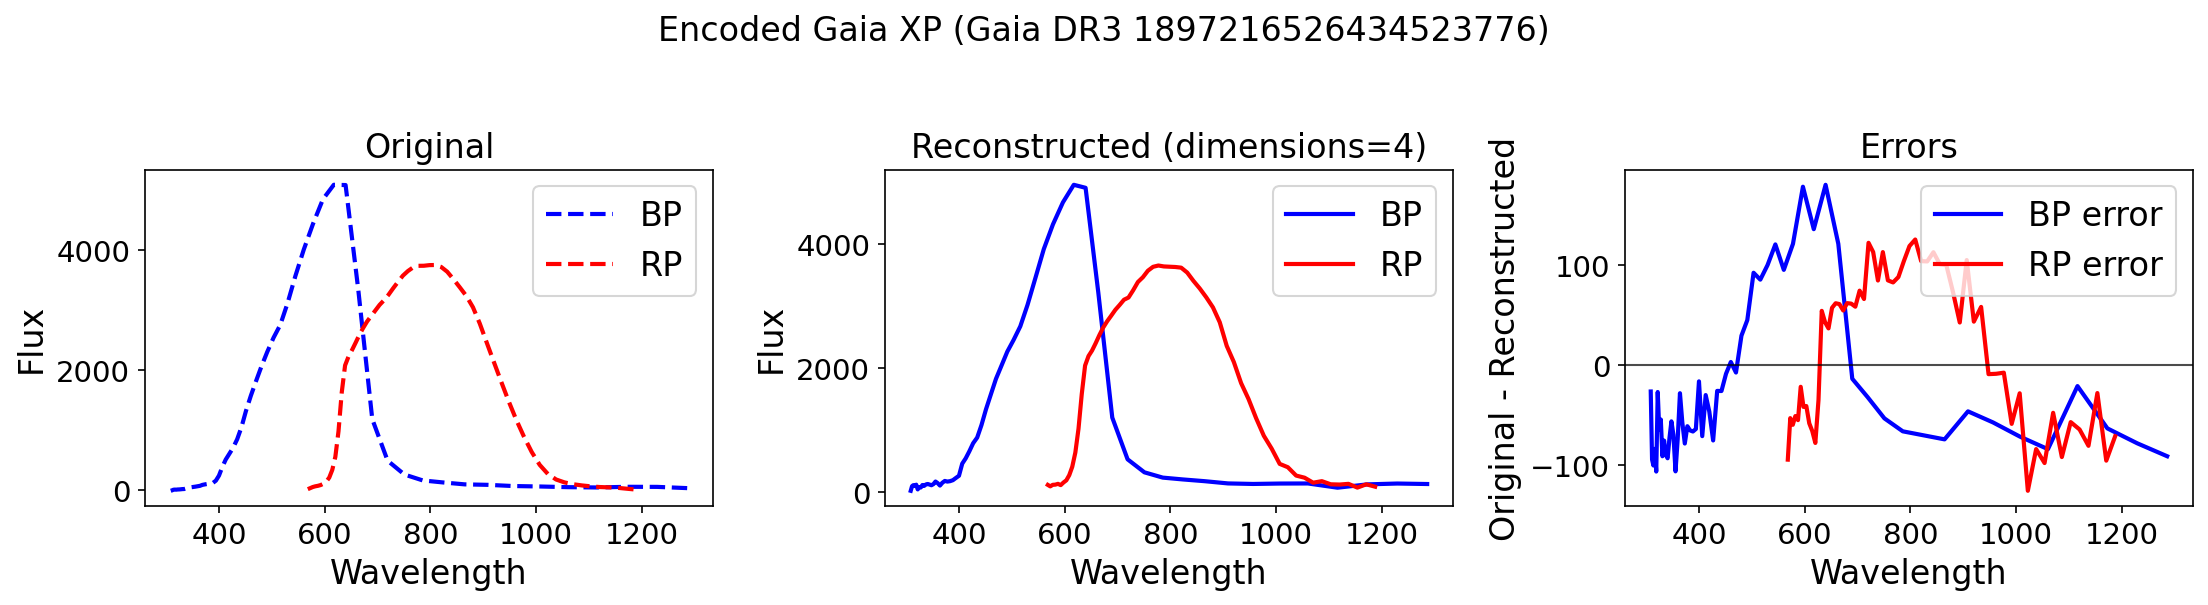

In [31]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4), dpi=150)

axs[0].plot(bp_wl, bp_flux, color="blue", lw=2, ls='--', label="BP")
axs[0].plot(rp_wl, rp_flux, color="red", lw=2, ls='--', label="RP")
axs[0].set_title("Original")
axs[0].set_xlabel("Wavelength")
axs[0].set_ylabel("Flux")
axs[0].legend()

axs[1].plot(bp_wl, bp_recon, color="blue", lw=2, label="BP")
axs[1].plot(rp_wl, rp_recon, color="red", lw=2, label="RP")
axs[1].set_title(f"Reconstructed (dimensions={dimensions})")
axs[1].set_xlabel("Wavelength")
axs[1].set_ylabel("Flux")
axs[1].legend()

axs[2].plot(bp_wl, bp_resid, color="blue", lw=2, label="BP error")
axs[2].plot(rp_wl, rp_resid, color="red", lw=2, label="RP error")
axs[2].axhline(0, color="black", lw=1, alpha=0.7)
axs[2].set_title("Errors")
axs[2].set_xlabel("Wavelength")
axs[2].set_ylabel("Original - Reconstructed")
axs[2].legend()

plt.suptitle(f"Encoded Gaia XP (Gaia DR3 {sid})", y=1.02)
plt.tight_layout()
plt.show()

**Discuss with your neighbour:** The middle plot shows the spectra after it was reconstructed from decoding those 4 numbers back into the original input length. The right plot shows the differences between the two. Do you think this simple autoencoeder works well?

Let's try a bunch of other dimensions, not just 4:

In [32]:
latent_dims = [4, 8, 16, 24, 32, 48, 64]

In [33]:
def train_autoencoder_for_dim(
    latent_dim,
    x_tensor,
    x_mean,
    x_std,
    n_bp,
    bp_flux,
    rp_flux,
    lr=1e-3,
    weight_decay=1e-5,
    dropout=0.1,
    max_epochs=5000,
    patience=200,
    min_delta=1e-6,
    device="cpu",
    verbose=False,
):
    model = AutoEncoder(
        input_dim=x_tensor.shape[1],
        latent_dim=latent_dim,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    loss_fn = nn.MSELoss()

    best_loss = float("inf")
    best_state = None
    wait = 0
    loss_history = []

    model.train()
    for epoch in range(max_epochs):
        optimizer.zero_grad()
        recon = model(x_tensor)
        loss = loss_fn(recon, x_tensor)
        loss.backward()
        optimizer.step()

        current_loss = float(loss.item())
        loss_history.append(current_loss)

        if current_loss < best_loss - min_delta:
            best_loss = current_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if verbose and epoch % 200 == 0:
            print(f"[d={latent_dim}] epoch={epoch}, loss={current_loss:.8f}, best={best_loss:.8f}")

        if wait >= patience:
            if verbose:
                print(f"[d={latent_dim}] early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        recon_norm = model(x_tensor).squeeze(0).cpu().numpy()

    recon_flux = recon_norm * x_std + x_mean

    bp_recon = recon_flux[:n_bp]
    rp_recon = recon_flux[n_bp:]

    bp_resid = bp_flux - bp_recon
    rp_resid = rp_flux - rp_recon

    result = {
        "latent_dim": latent_dim,
        "model": model,
        "best_loss": best_loss,
        "loss_history": loss_history,
        "bp_recon": bp_recon,
        "rp_recon": rp_recon,
        "bp_resid": bp_resid,
        "rp_resid": rp_resid,
    }
    return result

results = {}

for d in latent_dims:
    print(f"Training latent_dim = {d}")
    results[d] = train_autoencoder_for_dim(
        latent_dim=d,
        x_tensor=x_tensor,
        x_mean=x_mean,
        x_std=x_std,
        n_bp=n_bp,
        bp_flux=bp_flux,
        rp_flux=rp_flux,
        lr=1e-3,
        weight_decay=1e-5,
        dropout=0.1,
        max_epochs=5000,
        patience=200,
        min_delta=1e-6,
        device=device,
        verbose=False,
    )
    print(f"  best_loss = {results[d]['best_loss']:.8f}")

best_dim = min(results, key=lambda d: results[d]["best_loss"])
best_result = results[best_dim]

print("\nBest latent dimension:", best_dim)
print("Best loss:", best_result["best_loss"])

Training latent_dim = 4
  best_loss = 0.00157901
Training latent_dim = 8
  best_loss = 0.00076145
Training latent_dim = 16
  best_loss = 0.00164885
Training latent_dim = 24
  best_loss = 0.00196557
Training latent_dim = 32
  best_loss = 0.00070624
Training latent_dim = 48
  best_loss = 0.00135162
Training latent_dim = 64
  best_loss = 0.00041822

Best latent dimension: 64
Best loss: 0.00041821907507255673


And now let's look at the best one:

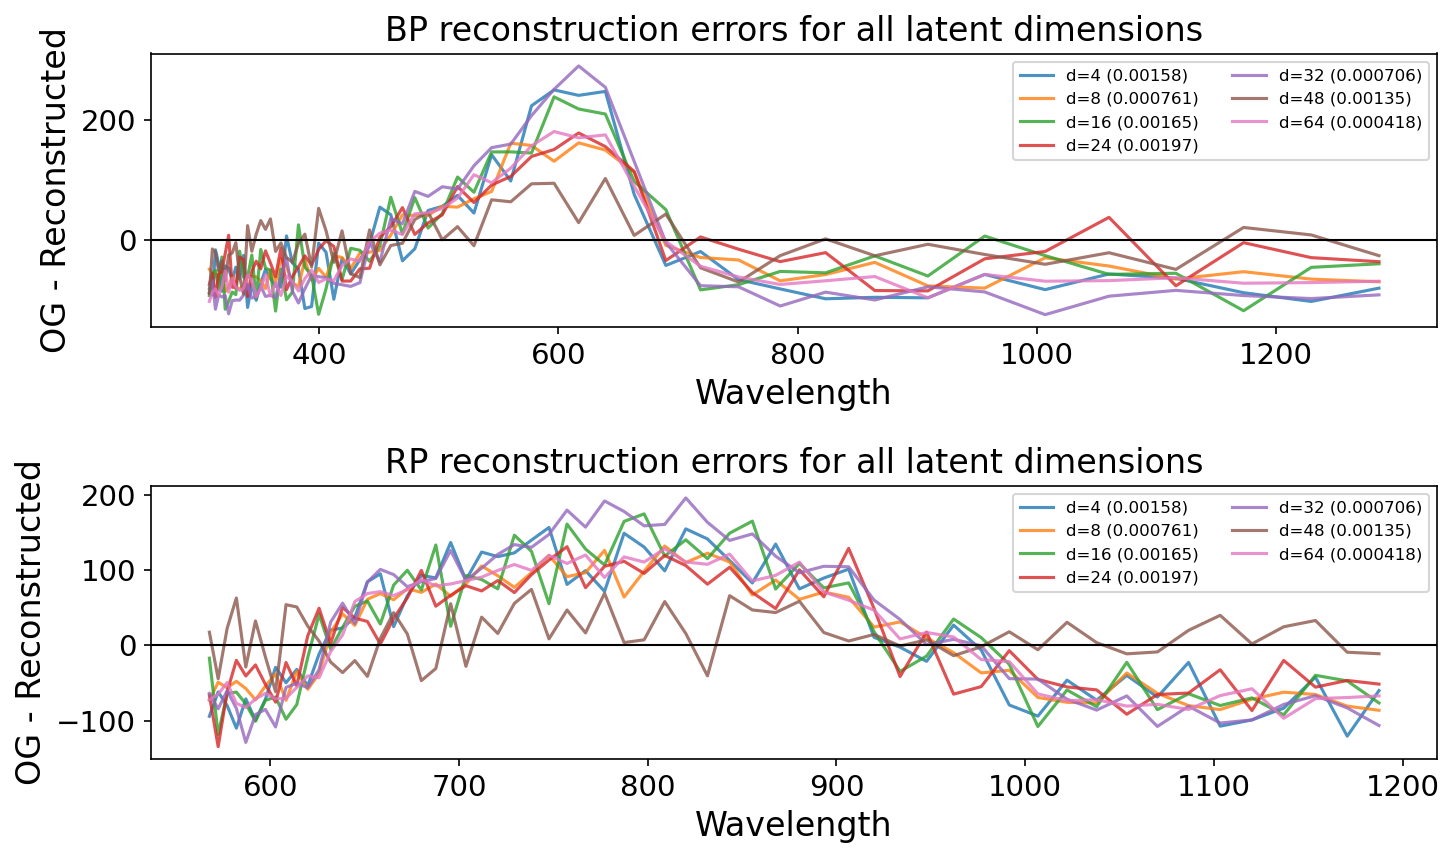

In [34]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6), dpi=150, sharex=False)

for d in latent_dims:
    axs[0].plot(
        bp_wl,
        results[d]["bp_resid"],
        lw=1.5,
        alpha=0.8,
        label=f"d={d} ({results[d]['best_loss']:.3g})"
    )

axs[0].axhline(0, color="black", lw=1)
axs[0].set_title("BP reconstruction errors for all latent dimensions")
axs[0].set_xlabel("Wavelength")
axs[0].set_ylabel("OG - Reconstructed")
axs[0].legend(fontsize=8, ncols=2)

for d in latent_dims:
    axs[1].plot(
        rp_wl,
        results[d]["rp_resid"],
        lw=1.5,
        alpha=0.8,
        label=f"d={d} ({results[d]['best_loss']:.3g})"
    )

axs[1].axhline(0, color="black", lw=1)
axs[1].set_title("RP reconstruction errors for all latent dimensions")
axs[1].set_xlabel("Wavelength")
axs[1].set_ylabel("OG - Reconstructed")
axs[1].legend(fontsize=8, ncols=2)

plt.tight_layout()
plt.show()

**Discuss with your neighbour:** Which -- BP or RP -- is more difficult to reconstruct based on this plot?

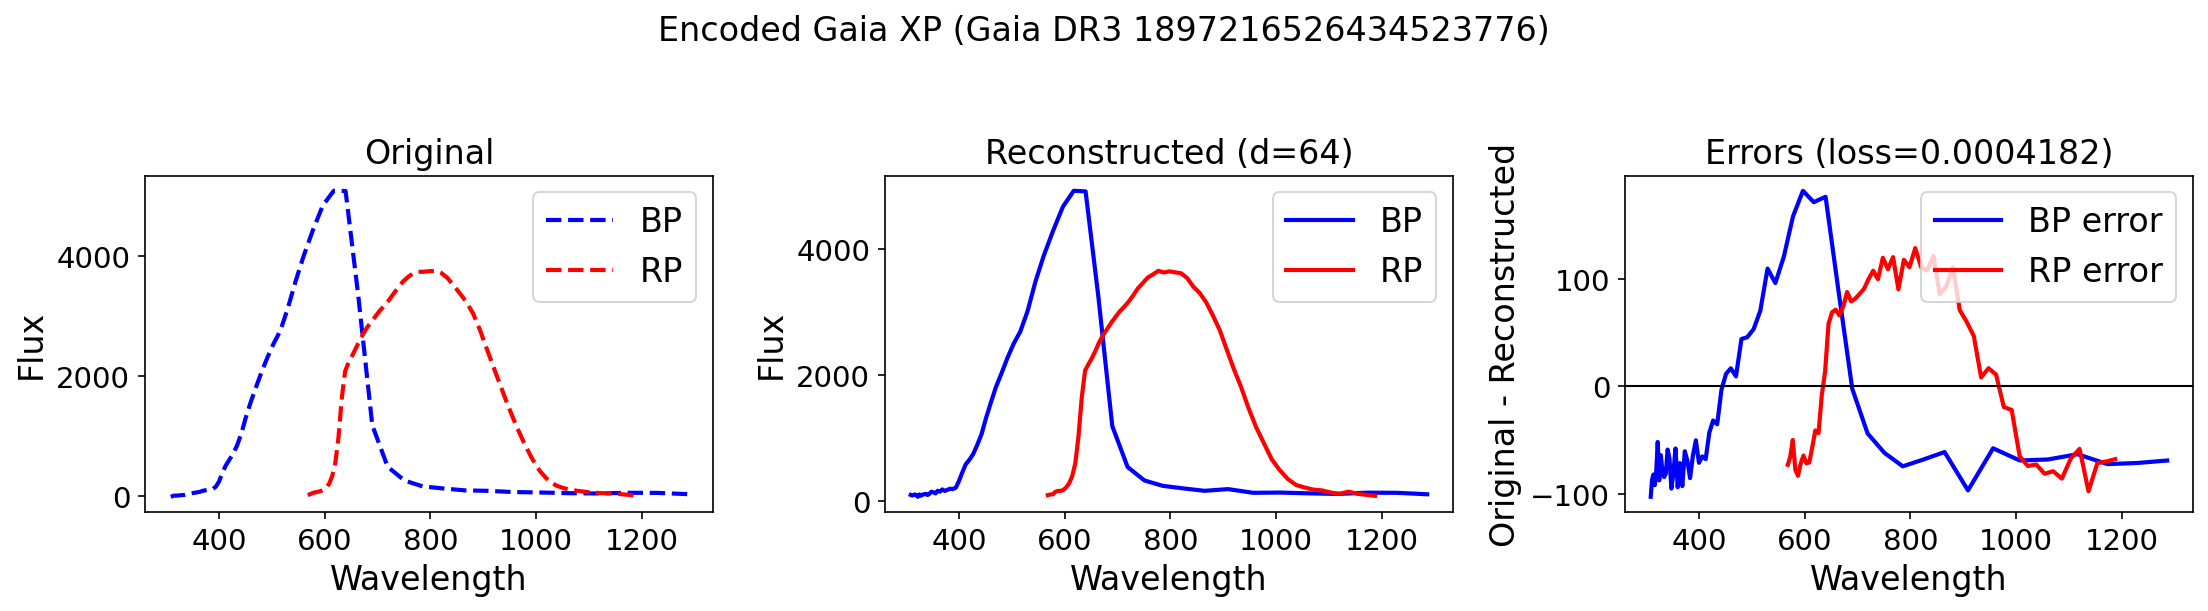

In [35]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4), dpi=150)

axs[0].plot(bp_wl, bp_flux, color="blue", lw=2, ls='--', label="BP")
axs[0].plot(rp_wl, rp_flux, color="red", lw=2, ls='--', label="RP")
axs[0].set_title("Original")
axs[0].set_xlabel("Wavelength")
axs[0].set_ylabel("Flux")
axs[0].legend()

axs[1].plot(bp_wl, best_result["bp_recon"], color="blue", lw=2, label="BP")
axs[1].plot(rp_wl, best_result["rp_recon"], color="red", lw=2, label="RP")
axs[1].set_title(f"Reconstructed (d={best_dim})")
axs[1].set_xlabel("Wavelength")
axs[1].set_ylabel("Flux")
axs[1].legend()

axs[2].plot(bp_wl, best_result["bp_resid"], color="blue", lw=2, label="BP error")
axs[2].plot(rp_wl, best_result["rp_resid"], color="red", lw=2, label="RP error")
axs[2].axhline(0, color="black", lw=1)
axs[2].set_title(f"Errors (loss={best_result['best_loss']:.4g})")
axs[2].set_xlabel("Wavelength")
axs[2].set_ylabel("Original - Reconstructed")
axs[2].legend()

plt.suptitle(f"Encoded Gaia XP (Gaia DR3 {sid})", y=1.03)
plt.tight_layout()
plt.show()

**Discuss with your neighbour:** We not found that 24 dimensions works best for Gaia. Do you think this is a generalizable result though?

### Leave-One-Out Cross-Validation

A few weeks ago we saw why we want to have a hold-out set. Let's consider a scenario where we will have a dataset of 40 spectra. This is too small to split, so we will train on 39 sources and validate on 1 hold-out source average the held-out reconstruction loss across all 40 folds and average the held-out reconstruction loss across all 40 folds.

In [19]:
# latent_dims = [4, 8, 16, 24, 32, 48, 64]
latent_dims = [4, 8, 16, 24] # I commented out the previois line because it will take awhile,
                             # feel free to uncommment it if you don't mind waiting

In [20]:
n_sources = 40
random_state = 42

device = "cuda" if torch.cuda.is_available() else "cpu"

lr = 1e-3
weight_decay = 1e-5
dropout = 0.1
max_epochs = 2000
patience = 100
min_delta = 1e-5
batch_size = 16

rng = np.random.default_rng(random_state)

all_sids = df.select("source_id").unique().to_series().to_list()
sampled_sids = rng.choice(all_sids, size=n_sources, replace=False).tolist()

In [21]:
def extract_source_vector(df: pl.DataFrame, sid):
    df_sid = df.filter(pl.col("source_id") == sid)

    bp = (
        df_sid.filter(pl.col("xp") == "BP")
              .select("flux")
              .to_series()
              .to_list()
    )
    rp = (
        df_sid.filter(pl.col("xp") == "RP")
              .select("flux")
              .to_series()
              .to_list()
    )

    if len(bp) != 1 or len(rp) != 1:
        return None

    bp_flux = np.asarray(bp[0], dtype=np.float32)
    rp_flux = np.asarray(rp[0], dtype=np.float32)

    return np.concatenate([bp_flux, rp_flux]).astype(np.float32)

X_list = []
kept_sids = []

for sid in sampled_sids:
    x = extract_source_vector(df, sid)
    if x is not None:
        X_list.append(x)
        kept_sids.append(sid)

X = np.stack(X_list)
sampled_sids = kept_sids

def train_one_fold(
    X_train,
    X_val,
    latent_dim,
    lr=1e-3,
    weight_decay=1e-5,
    dropout=0.1,
    max_epochs=2000,
    patience=100,
    min_delta=1e-5,
    batch_size=16,
    device="cpu",
):

    mu = X_train.mean(axis=0, keepdims=True)
    sigma = X_train.std(axis=0, keepdims=True)
    sigma = np.where(sigma < 1e-8, 1.0, sigma)

    X_train_n = (X_train - mu) / sigma
    X_val_n = (X_val - mu) / sigma

    X_train_t = torch.tensor(X_train_n, dtype=torch.float32, device=device)
    X_val_t = torch.tensor(X_val_n, dtype=torch.float32, device=device)

    train_loader = DataLoader(
        TensorDataset(X_train_t),
        batch_size=min(batch_size, len(X_train_t)),
        shuffle=True
    )

    model = AutoEncoder(
        input_dim=X_train.shape[1],
        latent_dim=latent_dim,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    wait = 0
    history = {"train": [], "val": []}

    for epoch in range(max_epochs):
        model.train()
        train_losses = []

        for (xb,) in train_loader:
            optimizer.zero_grad()
            recon = model(xb)
            loss = loss_fn(recon, xb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))

        model.eval()
        with torch.no_grad():
            val_recon = model(X_val_t)
            val_loss = float(loss_fn(val_recon, X_val_t).item())

        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if val_loss < best_val - min_delta:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        val_recon_n = model(X_val_t).cpu().numpy()

    val_recon = val_recon_n * sigma + mu
    resid = X_val - val_recon

    return {
        "model": model,
        "best_val_loss": best_val,
        "history": history,
        "mu": mu,
        "sigma": sigma,
        "val_recon": val_recon,
        "val_resid": resid,
    }

cv_results = {}

N = len(sampled_sids)

for d in latent_dims:
    print(f"\n=== latent_dim = {d} ===")
    fold_losses = []
    fold_outputs = []

    for i in range(N):
        X_val = X[i:i+1]
        X_train = np.concatenate([X[:i], X[i+1:]], axis=0)

        out = train_one_fold(
            X_train=X_train,
            X_val=X_val,
            latent_dim=d,
            lr=lr,
            weight_decay=weight_decay,
            dropout=dropout,
            max_epochs=max_epochs,
            patience=patience,
            min_delta=min_delta,
            batch_size=batch_size,
            device=device,
        )

        fold_losses.append(out["best_val_loss"])
        fold_outputs.append(out)

        print(f"  fold {i+1:02d}/{N}: val_loss = {out['best_val_loss']:.6f}")

    cv_results[d] = {
        "fold_losses": fold_losses,
        "mean_val_loss": float(np.mean(fold_losses)),
        "std_val_loss": float(np.std(fold_losses)),
        "fold_outputs": fold_outputs,
    }

    print(
        f"latent_dim={d} -> mean={cv_results[d]['mean_val_loss']:.6f}, "
        f"std={cv_results[d]['std_val_loss']:.6f}"
    )


=== latent_dim = 4 ===
  fold 01/40: val_loss = 0.000075
  fold 02/40: val_loss = 0.000045
  fold 03/40: val_loss = 0.000079
  fold 04/40: val_loss = 0.006538
  fold 05/40: val_loss = 0.000446
  fold 06/40: val_loss = 0.005862
  fold 07/40: val_loss = 0.000060
  fold 08/40: val_loss = 0.000028
  fold 09/40: val_loss = 0.313117
  fold 10/40: val_loss = 0.000055
  fold 11/40: val_loss = 0.000091
  fold 12/40: val_loss = 0.003819
  fold 13/40: val_loss = 0.000192
  fold 14/40: val_loss = 0.000053
  fold 15/40: val_loss = 1.060484
  fold 16/40: val_loss = 0.000064
  fold 17/40: val_loss = 0.029405
  fold 18/40: val_loss = 0.000228
  fold 19/40: val_loss = 0.000334
  fold 20/40: val_loss = 0.000259
  fold 21/40: val_loss = 0.000276
  fold 22/40: val_loss = 0.000212
  fold 23/40: val_loss = 0.000592
  fold 24/40: val_loss = 0.000050
  fold 25/40: val_loss = 0.359237
  fold 26/40: val_loss = 4.058112
  fold 27/40: val_loss = 0.014587
  fold 28/40: val_loss = 0.006303
  fold 29/40: val_loss =

In [22]:
best_dim = min(latent_dims, key=lambda d: cv_results[d]["mean_val_loss"])

print("\nBest latent dimension from LOOCV:", best_dim)
print("Best mean validation loss:", cv_results[best_dim]["mean_val_loss"])
print("Std validation loss:", cv_results[best_dim]["std_val_loss"])


Best latent dimension from LOOCV: 4
Best mean validation loss: 0.14669456009719398
Std validation loss: 0.6511615587675336


**Discuss with your neighbour:** Is it a different outcome than what we had for just one source? Is this something that you expected?

**To do (for the report):** For the report, you need to discuss how many latent dimensions you need to reconstruct the Gaia XP spectra. You can either focus one one source (doesn't have to be the one we had, can be another one), on doing more sources (40 or another number), or both. Either way is fine but please do include a loss value to explain why you came to thos conclusion. You can also choose to include one or more plots but it is up to you. Choose your own adventure :)